# Traffic Volume Forecasting using XGBoost
Complete pipeline.

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00,4918


In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
None
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [3]:
df['date_time'] = pd.to_datetime(
    df['date_time'],
    format='mixed',
    dayfirst=True
)
df['year']=df['date_time'].dt.year
df['month']=df['date_time'].dt.month
df['day']=df['date_time'].dt.day
df['hour']=df['date_time'].dt.hour
df['day_of_week']=df['date_time'].dt.dayofweek
df['is_weekend']=(df['day_of_week']>=5).astype(int)
df['hour_sin']=np.sin(2*np.pi*df['hour']/24)
df['hour_cos']=np.cos(2*np.pi*df['hour']/24)
df['lag_1']=df['traffic_volume'].shift(1)
df['lag_2']=df['traffic_volume'].shift(2)
df['lag_3']=df['traffic_volume'].shift(3)
df['lag_24']=df['traffic_volume'].shift(24)
df['rolling_mean_3']=df['traffic_volume'].shift(1).rolling(3).mean()
df['rolling_mean_24']=df['traffic_volume'].shift(1).rolling(24).mean()
df=df.dropna()
df=pd.get_dummies(df,columns=['holiday','weather_main','weather_description'],drop_first=True)
df=df.drop(columns=['date_time'])

In [4]:
from sklearn.model_selection import train_test_split
X=df.drop('traffic_volume',axis=1)
y=df['traffic_volume']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [5]:
from xgboost import XGBRegressor
model=XGBRegressor(
        n_estimators=500,
        learning_rate=0.01,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
)
model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [6]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
pred=model.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,pred)))
print('R2',r2_score(y_test,pred))

MAE 118.49047088623047
RMSE 152.12389584644484
R2 0.7148491740226746


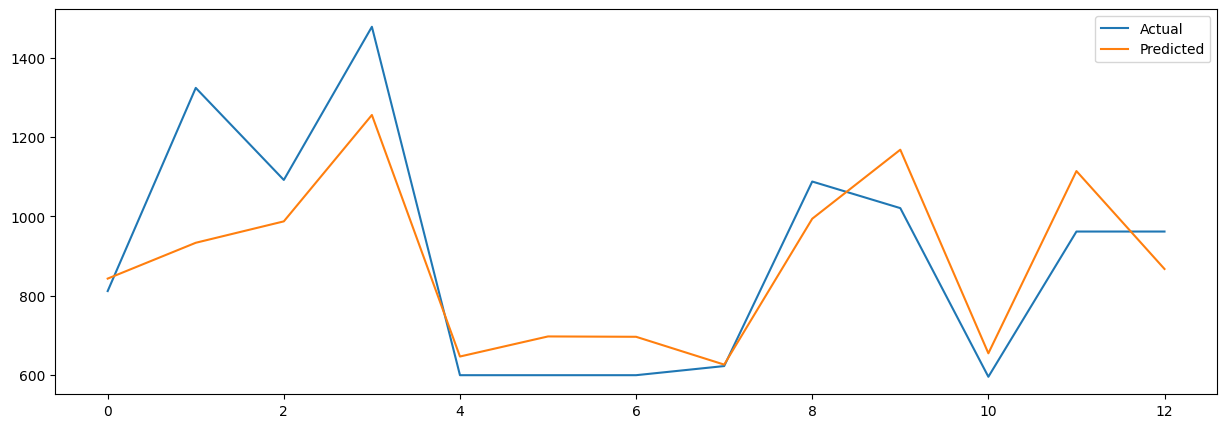

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:300],label='Actual')
plt.plot(pred[:300],label='Predicted')
plt.legend()
plt.show()

In [8]:
# import joblib
# joblib.dump(model,'xgboost_traffic_model.pkl')

### Predict traffic
Create a feature row with the same columns as X_train and call:
```python
prediction=model.predict(new_data)
```
For a 24-hour forecast, create one row per hour and predict sequentially.